In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [208]:
df = pd.read_csv('titanic_data_set.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [210]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

***Deleting Unnecessary Features***

In [211]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


***separating features and target columns***

In [212]:
# features 
x = df.drop(['Survived'], axis=1)

In [213]:
# target 
y = df['Survived']

***Train Test Split***

In [214]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

***Imputing Missing Values***

***Neumerical Values***

In [215]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

***By Pandas***

***Mean Impute***

In [216]:
# age
age_mean = x_train['Age'].mean()
x_train['Age'].fillna(age_mean)

# fare
fare_mean = x_train['Fare'].mean()
x_train['Fare'].fillna(fare_mean)

331     28.5000
733     13.0000
382      7.9250
704      7.8542
813     31.2750
         ...   
106      7.6500
270     31.0000
860     14.1083
435    120.0000
102     77.2875
Name: Fare, Length: 712, dtype: float64

In [217]:
# age
age_mean = x_test['Age'].mean()
x_test['Age'].fillna(age_mean)

# fare
fare_mean = x_test['Fare'].mean()
x_test['Fare'].fillna(fare_mean)

709    15.2458
439    10.5000
840     7.9250
720    33.0000
39     11.2417
        ...   
433     7.1250
773     7.2250
25     31.3875
84     10.5000
10     16.7000
Name: Fare, Length: 179, dtype: float64

***Simple Imputor of Numerical Values***

In [218]:
# Age (by mean)
age_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputor.fit(x_train[['Age']])

x_train['Age'] = age_imputor.transform(x_train[['Age']]).ravel()
x_test['Age'] = age_imputor.transform(x_test[['Age']]).ravel()

***Simple Imputor of Categrical Values***

In [219]:
# Embarked
embarked_imputor = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputor.fit(x_train[['Embarked']])

x_train['Embarked'] = embarked_imputor.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imputor.transform(x_test[['Embarked']]).ravel()

In [220]:
# Cabin
cabin_imputor = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

cabin_imputor.fit(x_train[['Cabin']])

x_train[['Cabin', 'missing_indicator']] = cabin_imputor.transform(x_train[['Cabin']])
x_test[['Cabin', 'missing_indicator']] = cabin_imputor.transform(x_test[['Cabin']])

In [221]:
df.sample(3) 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
573,yes,third,female,NaN,0,0,7.75,NaN,Q
238,no,second,male,19.0,0,0,10.50,NaN,S
740,yes,first,male,NaN,0,0,30.00,D45,S


In [222]:
x_train.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_indicator
38,third,female,18.0,2,0,18.0000,Missing,S,True
753,third,male,23.0,0,0,7.8958,Missing,S,True
1,first,female,38.0,1,0,71.2833,C85,C,False


# Encoding

***Ordinal Encoding***

In [223]:
from sklearn.preprocessing import OrdinalEncoder

**Pclass**

In [224]:
# object
pclass_encoder = OrdinalEncoder(categories=[['third', 'second', 'first']])

# fit
pclass_encoder.fit(x_train[['Pclass']])

# transform
x_train['encoded_Pclass'] = pclass_encoder.transform(x_train[['Pclass']]).ravel()
x_test['encoded_Pclass'] = pclass_encoder.transform(x_test[['Pclass']]).ravel()

In [225]:
x_train.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_indicator,encoded_Pclass
542,third,female,11.000000,4,2,31.275,Missing,S,True,0.0
560,third,male,29.498846,0,0,7.750,Missing,Q,True,0.0
41,second,female,27.000000,1,0,21.000,Missing,S,True,1.0


In [226]:
x_test.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_indicator,encoded_Pclass
198,third,female,29.498846,0,0,7.750,Missing,Q,True,0.0
840,third,male,20.000000,0,0,7.925,Missing,S,True,0.0
244,third,male,30.000000,0,0,7.225,Missing,C,True,0.0


***One Hot Encoding***

In [227]:
from sklearn.preprocessing import OneHotEncoder

**Gender**

In [228]:
# object
sex_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas') 

# fit
sex_encoder.fit(x_train[['Sex']])

# transform
ohe_df_train = sex_encoder.transform(x_train[['Sex']])
ohe_df_test = sex_encoder.transform(x_test[['Sex']])

# concatenate
x_train = pd.concat([x_train, ohe_df_train], axis=1)
x_test = pd.concat([x_test, ohe_df_test], axis=1)

**Embarked**

In [229]:
# object
embarked_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

# fit
embarked_encoder.fit(x_train[['Embarked']])

# transform
ohe_df_train = embarked_encoder.transform(x_train[['Embarked']])
ohe_df_test = embarked_encoder.transform(x_test[['Embarked']])

# concatenate
x_train = pd.concat([x_train, ohe_df_train], axis=1)
x_test = pd.concat([x_test, ohe_df_test], axis=1)

In [230]:
x_train.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
131,third,male,20.0,0,0,7.0500,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
566,third,male,19.0,0,0,7.8958,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
798,third,male,30.0,0,0,7.2292,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0


In [231]:
x_test.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
227,third,male,20.500000,0,0,7.2500,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
65,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
462,first,male,47.000000,0,0,38.5000,E63,S,False,2.0,0.0,1.0,0.0,0.0,1.0


**Drop**

In [232]:
x_train.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)
x_train.sample(3)

,Age,SibSp,Parch,Fare,Cabin,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
368,29.498846,0,0,7.7500,Missing,True,0.0,1.0,0.0,0.0,1.0,0.0
786,18.000000,0,0,7.4958,Missing,True,0.0,1.0,0.0,0.0,0.0,1.0
743,24.000000,1,0,16.1000,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0


In [233]:
x_test.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)
x_test.sample(3)

,Age,SibSp,Parch,Fare,Cabin,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
281,28.0,0,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
309,30.0,0,0,56.9292,E36,False,2.0,1.0,0.0,1.0,0.0,0.0
323,22.0,1,1,29.0000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0


***Cabin***

In [234]:
x_train['Cabin'].value_counts()

Cabin
Missing        553
C23 C25 C27      4
B96 B98          3
G6               3
C22 C26          3
              ... 
C104             1
D11              1
C86              1
C7               1
C62 C64          1
Name: count, Length: 118, dtype: int64

In [235]:
x_train['Cabin_Deck'] = x_train['Cabin'].astype(str).str[0]
x_test['Cabin_Deck'] = x_test['Cabin'].astype(str).str[0]

In [236]:
x_train['Cabin_Deck'].value_counts()

Cabin_Deck
M    553
C     52
B     38
E     24
D     19
F     12
A     10
G      3
T      1
Name: count, dtype: int64

In [237]:
x_test['Cabin_Deck'].value_counts()

Cabin_Deck
M    134
D     14
B      9
E      8
C      7
A      5
F      1
G      1
Name: count, dtype: int64

In [238]:
# one hot encoding

# object
cabin_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

# fit
cabin_encoder.fit(x_train[['Cabin_Deck']])

# transform
ohe_df_train = cabin_encoder.transform(x_train[['Cabin_Deck']])
ohe_df_test = cabin_encoder.transform(x_test[['Cabin_Deck']])

# concatenate
x_train = pd.concat([x_train, ohe_df_train], axis=1)
x_test = pd.concat([x_test, ohe_df_test], axis=1)

In [239]:
x_train.drop(['Cabin'], axis=1, inplace=True)
x_train.sample(3)

,Age,SibSp,Parch,Fare,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
608,22.0,1,2,41.5792,True,1.0,1.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
361,29.0,1,0,27.7208,True,1.0,0.0,1.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
737,35.0,0,0,512.3292,False,2.0,0.0,1.0,1.0,0.0,...,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [240]:
x_test.drop(['Cabin'], axis=1, inplace=True)
x_test.sample(3)

,Age,SibSp,Parch,Fare,missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
673,31.0,0,0,13.0,True,1.0,0.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
462,47.0,0,0,38.5,False,2.0,0.0,1.0,0.0,0.0,...,E,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
319,40.0,1,1,134.5,False,2.0,1.0,0.0,1.0,0.0,...,E,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


***Label Encoding***

In [241]:
from sklearn.preprocessing import LabelEncoder

In [242]:
y_train.sample(3)

564    no
847    no
824    no
Name: Survived, dtype: object

In [243]:
# object
le = LabelEncoder()

# fit
le.fit(y_train)

# transform
encoded_Ytrain = le.transform(y_train)
encoded_Ytest = le.transform(y_test)

In [244]:
encoded_Ytrain

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [245]:
encoded_Ytest

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [246]:
encoded_Ytrain = pd.Series(encoded_Ytrain, index=y_train.index)
encoded_Ytrain.sample(3)

121    0
315    1
781    1
dtype: int64

In [247]:
encoded_Ytest = pd.Series(encoded_Ytest, index=y_test.index)
encoded_Ytest.sample(3)

426    1
198    1
545    0
dtype: int64

# Scaling

<Axes: xlabel='Age', ylabel='Density'>

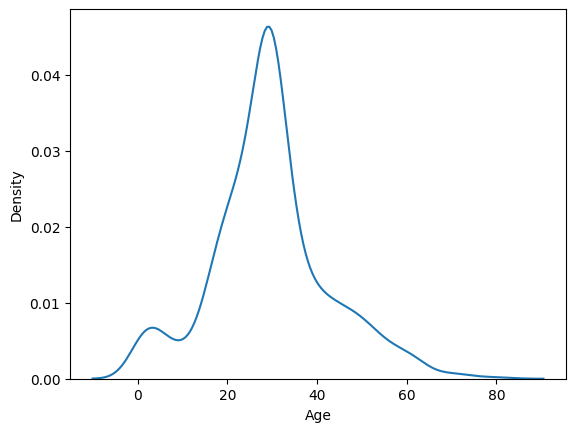

In [248]:
sns.kdeplot(data=x_train, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

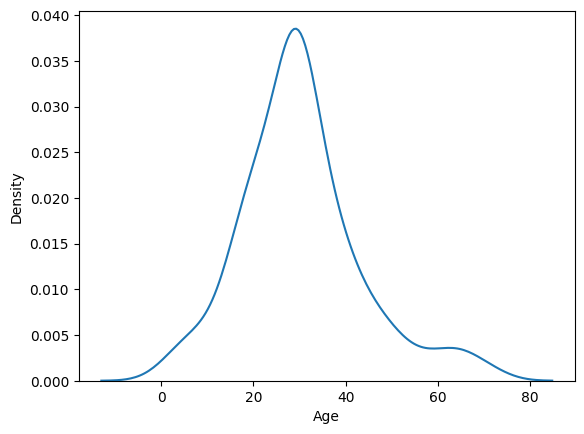

In [249]:
sns.kdeplot(data=x_test, x='Age')

***Standard Scaling***

In [250]:
from sklearn.preprocessing import StandardScaler

In [251]:
# object
ss = StandardScaler()

# fit
ss.fit(x_train[['Age']])

# transform
x_train['Age'] = ss.transform(x_train[['Age']]).ravel()
x_test['Age'] = ss.transform(x_test[['Age']]).ravel()

In [252]:
print(f"Mean of x_train Age: {round(x_train['Age'].mean(), 5)}")
print(f"Mean of x_test Age: {round(x_test['Age'].mean(), 5)}")
print(f"Standard Deviation of x_train Age : {round(x_train['Age'].std(), 5)}")
print(f"Standard Deviation of x_test  Age : {round(x_test['Age'].std(), 5)}")

Mean of x_train Age: 0.0
Mean of x_test Age: 0.06152
Standard Deviation of x_train Age : 1.0007
Standard Deviation of x_test  Age : 1.00505


<Axes: xlabel='Age', ylabel='Density'>

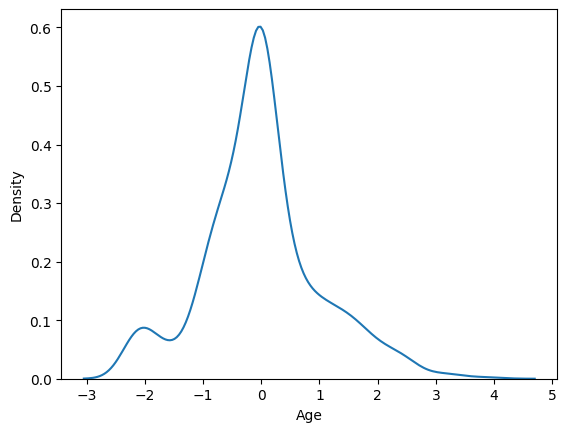

In [253]:
sns.kdeplot(data=x_train, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

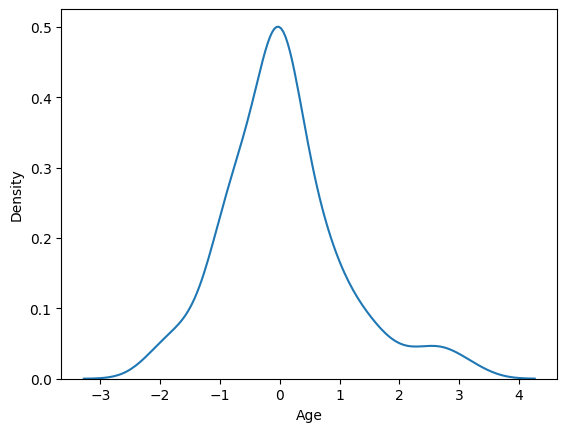

In [254]:
sns.kdeplot(data=x_test, x='Age')